In [28]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax.experimental.jet import jet
from jax.tree_util import Partial
from flax import nnx

# Others
from matplotlib import pyplot as plt

# Defaults
from typing import *

# Ours
from utils import *

What does a neural kernel look like?
How do I define my kernels?

GMM fn:
- Takes:
    - Scenario vector (s,)
    - Coeffs? (?,)
    - Updated StD bool
- Returns:
    - LnSA array
    - Aleatory StD array

Variance fn:
- Returns:
    - Variance float

Covariance matrix fn:
- Returns:
    - Covariance array (n, n)
    - parameter array (n, s)

Kernel class:
- Takes for instantiation:
    - Parameter indices
    - RNG?
- Takes for fitting:
    - Parameter array
    - covariance array
- Takes for inference (after fitting):
    - Parameter array
- Returns for inference (after fitting):
    - Float (vmap to array)


KL expansion:

PCE:

Full GP?:

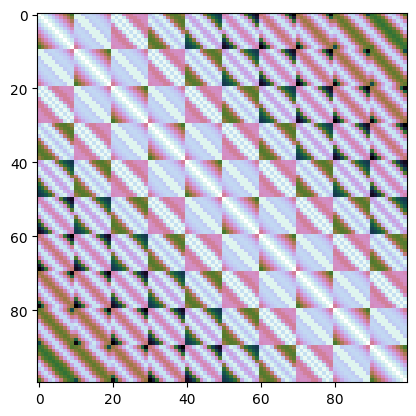

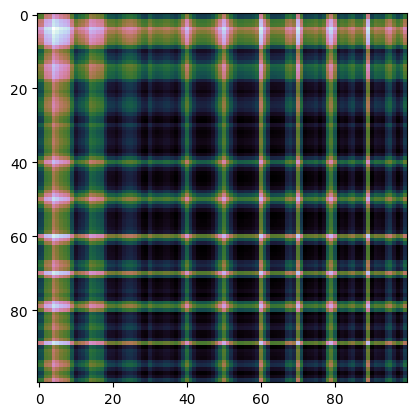

In [ ]:
class snk(nnx.Module):
    def __init__(self, in_dim:int, 
                       hidden_dim:int, 
                       hidden_num:int,
                       activation:Callable = nnx.relu, 
                       rngs:nnx.Rngs = nnx.Rngs(1)):
        self.activation = activation
        self.in_ffn = nnx.Linear(in_dim, hidden_dim, rngs = rngs)
        self.h_ffns = [nnx.Linear(hidden_dim, hidden_dim, rngs = rngs) for i in range(hidden_num)]
        self.out_ffn = nnx.Linear(hidden_dim, 1, rngs = rngs)

    def __call__(self, x1x2):
        x1, x2 = x1x2[0], x1x2[1]
        x = jnp.abs(x1 - x2)
        x = self.activation(self.in_ffn(x))
        for h_ffn in self.h_ffns:
            x = self.activation(h_ffn(x))
        x = self.out_ffn(x)
        return x
    
class nsnk(nnx.Module):
    def __init__(self, in_dim:int, 
                       hidden_dim:int, 
                       hidden_num:int,
                       activation:Callable = nnx.relu, 
                       rngs:nnx.Rngs = nnx.Rngs(1)):
        self.activation = activation
        self.in_ffn = nnx.Linear(in_dim, hidden_dim, rngs = rngs)
        self.h_ffns = [nnx.Linear(hidden_dim, hidden_dim, rngs = rngs) for i in range(hidden_num)]
        self.out_ffn = nnx.Linear(hidden_dim, 1, rngs = rngs)

    def __call__(self, x1x2):
        x1, x2 = x1x2[0], x1x2[1]
        x1, x2 = self.activation(self.in_ffn(x1)), self.activation(self.in_ffn(x2))
        for h_ffn in self.h_ffns:
            x1, x2 = self.activation(h_ffn(x1)), self.activation(h_ffn(x2))
        x = self.out_ffn(x1) ** 2 + self.out_ffn(x2) ** 2
        return x